Total edge crack frames found: 15

GT frames found: ['frame_1.jpg', 'frame_2.jpg', 'frame_3.jpg', 'frame_4.jpg', 'frame_5.jpg', 'frame_39.jpg', 'frame_40.jpg', 'frame_41.jpg', 'frame_42.jpg', 'frame_43.jpg', 'frame_97.jpg', 'frame_98.jpg', 'frame_99.jpg', 'frame_100.jpg', 'frame_101.jpg']

Frames with ground truth masks: 15

Testing on first frame...


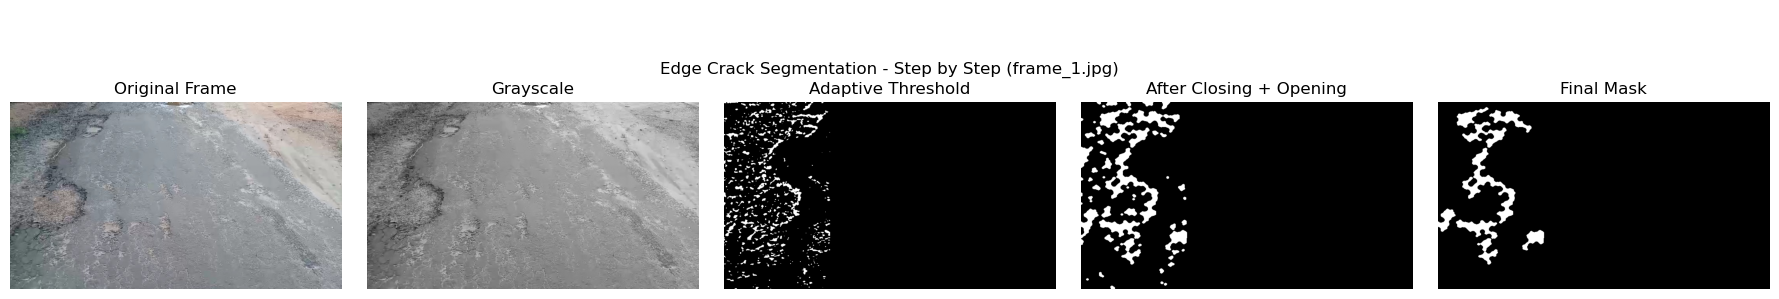

Test done. Check the step-by-step image saved in Member2_Segmentation/

Processing all edge crack frames...
Done. All outputs saved in: Member2_Segmentation/


Evaluation Metrics (Frames with Ground Truth)
Frame                  Accuracy  Precision     Recall         F1        IoU       Dice
----------------------------------------------------------------------------------
frame_1.jpg              0.9126     0.5563     0.2728     0.3661     0.2241     0.3661
frame_2.jpg              0.9230     0.5646     0.3686     0.4460     0.2870     0.4460
frame_3.jpg              0.9047     0.5980     0.3015     0.4009     0.2507     0.4009
frame_4.jpg              0.9064     0.6280     0.3449     0.4452     0.2864     0.4452
frame_5.jpg              0.8965     0.5605     0.3272     0.4131     0.2604     0.4131
frame_39.jpg             0.9595     0.4788     0.3625     0.4126     0.2599     0.4126
frame_40.jpg             0.9532     0.4828     0.2708     0.3470     0.2099     0.3470
frame_41.jpg   

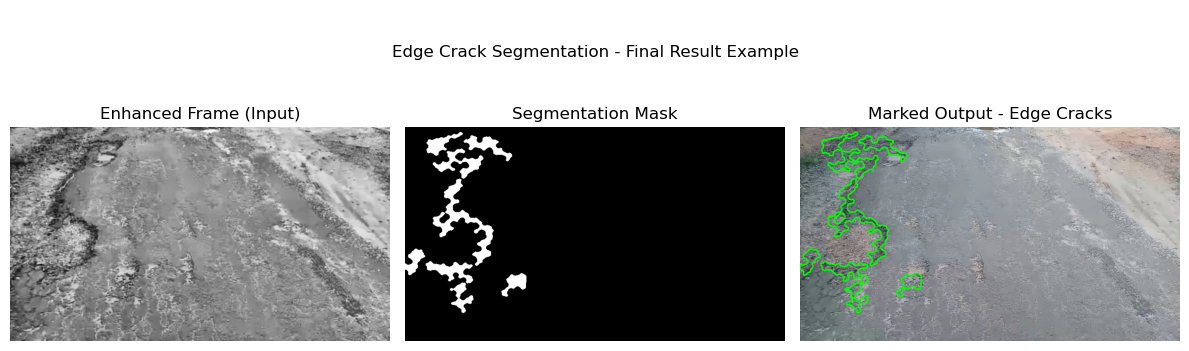

Report example image saved: Member2_Segmentation/report_example.jpg

Check the folder: Member2_Segmentation/
Files saved:
  mask_*.jpg             - Binary segmentation masks
  marked_*.jpg           - Frames with edge cracks highlighted in green
  comparison_*.jpg       - Side by side: Enhanced | Mask | Marked
  test_steps_*.jpg       - Step by step processing stages
  report_example.jpg     - Clean 3-panel image for the report
  edgecrack_metrics.txt  - Accuracy, Precision, Recall, F1, IoU, Dice


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Step 1: Set Up Folders

input_folder  = "Final_Enhanced/"
gt_folder     = "GroundTruth_EdgeCracks/"
output_folder = "Member2_Segmentation/"

os.makedirs(output_folder, exist_ok=True)

# Step 2: Read Edge Crack Frame Names

crack_input = "Frames_EdgeCracks/"

all_files = os.listdir(crack_input)

frame_files = []
for f in all_files:
    if f.endswith(".jpg"):
        frame_files.append(f)

# Sort by frame number
frame_files.sort(key=lambda x: int(x.split("_")[1].split(".")[0]))

print("Total edge crack frames found:", len(frame_files))

# Step 3: Check Which Frames Have Ground Truth Masks
# ---------------------------------------------------
# Supports both .jpg and .png ground truth mask files

frames_with_gt = []
for f in frame_files:
    gt_path_jpg = gt_folder + f
    gt_path_png = gt_folder + f.replace(".jpg", ".png")
    if os.path.exists(gt_path_jpg):
        frames_with_gt.append(f)
    elif os.path.exists(gt_path_png):
        frames_with_gt.append(f)

print("\nGT frames found:", frames_with_gt)
print("\nFrames with ground truth masks:", len(frames_with_gt))

if len(frames_with_gt) == 0:
    print("WARNING: No ground truth masks found in", gt_folder)
    for f in os.listdir(gt_folder):
        print("  ->", f)
    for f in frame_files:
        print("  ->", f)

# Step 4: Define Edge Crack Segmentation Function
# --------------------------------------------------------------
# This function takes one frame image and returns a binary mask
# where WHITE = detected edge crack region
#       BLACK = background / non-crack area

def segment_edge_cracks(img):

    H, W = img.shape[:2]

    # Convert to HSV for color-based filtering
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Convert to grayscale for thresholding
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Focus on left edge zone only — edge cracks appear on left side of road
    left_width = int(W * 0.32)
    left_gray  = gray[:, :left_width]
    left_hsv   = hsv[:, :left_width]

    # Remove grass regions
    # Grass has green hue in HSV color space
    lower_green = np.array([25, 30, 30])
    upper_green = np.array([90, 255, 255])
    grass_mask  = cv2.inRange(left_hsv, lower_green, upper_green)

    # Remove bright sandy/soil off-road areas
    # Sandy areas are bright and have low saturation
    lower_sand  = np.array([0, 0, 180])
    upper_sand  = np.array([30, 50, 255])
    sand_mask   = cv2.inRange(left_hsv, lower_sand, upper_sand)

    # Combine grass and sand into one exclusion mask
    exclude_left = cv2.bitwise_or(grass_mask, sand_mask)

    # Gaussian Blur
    # Reduces road texture noise before thresholding
    blurred = cv2.GaussianBlur(left_gray, (7, 7), 0)

    # Adaptive Gaussian Thresholding
    # blockSize=51, C=10 works consistently across different lighting conditions
    # Detects dark crack regions relative to surrounding area
    binary = cv2.adaptiveThreshold(blurred, 255,
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV,
                                   51, 10)

    # Remove grass and sand pixels from the detected binary mask
    binary = cv2.bitwise_and(binary, cv2.bitwise_not(exclude_left))

    # Place left zone result back into full image size canvas
    binary_full = np.zeros((H, W), dtype=np.uint8)
    binary_full[:, :left_width] = binary

    #  Morphological Closing 
    # Connects broken crack regions and fills gaps between fragments
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
    closed = cv2.morphologyEx(binary_full, cv2.MORPH_CLOSE, kernel_close)

    #  Morphological Opening 
    # Removes small noise dots that are not real cracks
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)

    #  Fill Holes Inside Contours 
    # Draws filled contours to remove black holes inside detected regions
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(cleaned)
    for cnt in contours:
        cv2.drawContours(filled, [cnt], -1, 255, -1)

    #  Connected Components Filtering 
    # Keep only large connected regions — minimum 800 pixels
    # This removes remaining small false positive dots
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(filled)
    final_mask = np.zeros_like(filled)
    min_area   = 800

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            final_mask[labels == i] = 255

    return final_mask

# Step 5: Test on First Frame - Check Output Visually

print("\nTesting on first frame...")

test_name = frame_files[0]
test_img  = cv2.imread(crack_input + test_name)

if test_img is None:
    print("Could not read the first frame. Check the folder path.")
else:

    # Run each step separately for visualization
    gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)
    H, W = test_img.shape[:2]
    left_width = int(W * 0.32)
    left_gray  = gray[:, :left_width]
    blurred    = cv2.GaussianBlur(left_gray, (7, 7), 0)

    binary_left = cv2.adaptiveThreshold(blurred, 255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY_INV,
                                        51, 10)

    # Place into full image for visualization
    binary_full = np.zeros((H, W), dtype=np.uint8)
    binary_full[:, :left_width] = binary_left

    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
    closed = cv2.morphologyEx(binary_full, cv2.MORPH_CLOSE, kernel_close)

    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)

    # Get final result from function
    final_mask = segment_edge_cracks(test_img)

    # Show all processing steps side by side
    plt.figure(figsize=(18, 3))

    plt.subplot(1, 5, 1)
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Frame")
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(binary_full, cmap='gray')
    plt.title("Adaptive Threshold")
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(cleaned, cmap='gray')
    plt.title("After Closing + Opening")
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(final_mask, cmap='gray')
    plt.title("Final Mask")
    plt.axis('off')

    plt.suptitle("\n\n\nEdge Crack Segmentation - Step by Step (" + test_name + ")")
    plt.tight_layout()
    plt.savefig(output_folder + "test_steps_" + test_name)
    plt.show()

    print("Test done. Check the step-by-step image saved in", output_folder)

# Step 6: Process All Edge Crack Frames

print("\nProcessing all edge crack frames...")

for frame_name in frame_files:

    img = cv2.imread(crack_input + frame_name)

    if img is None:
        print("Could not read:", frame_name, "- Skipping.")
        continue

    # Run segmentation function
    final_mask = segment_edge_cracks(img)

    # Find contours of detected crack regions
    contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    # Draw green contours on a copy of the original frame
    marked = img.copy()
    cv2.drawContours(marked, contours, -1, (0, 255, 0), 2)

    # Save binary mask
    cv2.imwrite(output_folder + "mask_" + frame_name, final_mask)

    # Save marked frame with green crack outlines
    cv2.imwrite(output_folder + "marked_" + frame_name, marked)

    # Save side-by-side comparison: Enhanced | Mask | Marked
    enhanced_bgr = cv2.imread(input_folder + frame_name)
    if enhanced_bgr is None:
        enhanced_bgr = img

    mask_bgr   = cv2.cvtColor(final_mask, cv2.COLOR_GRAY2BGR)
    comparison = np.hstack((enhanced_bgr, mask_bgr, marked))
    cv2.imwrite(output_folder + "comparison_" + frame_name, comparison)

print("Done. All outputs saved in:", output_folder)

# Step 7: Calculate Evaluation Metrics
# ---------------------------------------------------------
# Compare predicted mask against ground truth mask pixel by pixel
# TP = both predict crack and GT says crack
# FP = predict crack but GT says no crack
# FN = predict no crack but GT says crack
# TN = both predict no crack

print("\n\nEvaluation Metrics (Frames with Ground Truth)")
print(f"{'Frame':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'IoU':>10} {'Dice':>10}")
print("-" * 82)

results = []

for frame_name in frames_with_gt:

    img = cv2.imread(crack_input + frame_name)

    # Load ground truth mask — supports both .jpg and .png
    gt_path = gt_folder + frame_name
    if not os.path.exists(gt_path):
        gt_path = gt_folder + frame_name.replace(".jpg", ".png")
    gt_img = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    if img is None or gt_img is None:
        print("Could not read:", frame_name, "- Skipping.")
        continue

    # Run segmentation
    final_mask = segment_edge_cracks(img)

    # Resize GT to match predicted mask size
    gt_img = cv2.resize(gt_img, (final_mask.shape[1], final_mask.shape[0]))

    # Convert both masks to binary (0 and 1)
    _, gt_bin   = cv2.threshold(gt_img,     127, 1, cv2.THRESH_BINARY)
    _, pred_bin = cv2.threshold(final_mask, 127, 1, cv2.THRESH_BINARY)

    # Count TP, FP, FN, TN
    TP = int(np.sum((pred_bin == 1) & (gt_bin == 1)))
    FP = int(np.sum((pred_bin == 1) & (gt_bin == 0)))
    FN = int(np.sum((pred_bin == 0) & (gt_bin == 1)))
    TN = int(np.sum((pred_bin == 0) & (gt_bin == 0)))

    total    = TP + FP + FN + TN
    accuracy = (TP + TN) / total

    if (TP + FP) == 0:
        precision = 0.0
    else:
        precision = TP / (TP + FP)

    if (TP + FN) == 0:
        recall = 0.0
    else:
        recall = TP / (TP + FN)

    if (precision + recall) == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    if (TP + FP + FN) == 0:
        iou = 0.0
    else:
        iou = TP / (TP + FP + FN)

    if (2 * TP + FP + FN) == 0:
        dice = 0.0
    else:
        dice = (2 * TP) / (2 * TP + FP + FN)

    results.append([frame_name, accuracy, precision, recall, f1, iou, dice])

    print(f"{frame_name:<20} {accuracy:>10.4f} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {iou:>10.4f} {dice:>10.4f}")

# Step 8: Calculate and Print Averages

avg_acc = 0
avg_pre = 0
avg_rec = 0
avg_f1  = 0
avg_iou = 0
avg_dic = 0

if len(results) > 0:

    total_acc = 0
    total_pre = 0
    total_rec = 0
    total_f1  = 0
    total_iou = 0
    total_dic = 0

    for r in results:
        total_acc = total_acc + r[1]
        total_pre = total_pre + r[2]
        total_rec = total_rec + r[3]
        total_f1  = total_f1  + r[4]
        total_iou = total_iou + r[5]
        total_dic = total_dic + r[6]

    count = len(results)

    avg_acc = total_acc / count
    avg_pre = total_pre / count
    avg_rec = total_rec / count
    avg_f1  = total_f1  / count
    avg_iou = total_iou / count
    avg_dic = total_dic / count

    print("-" * 82)
    print(f"{'AVERAGE':<20} {avg_acc:>10.4f} {avg_pre:>10.4f} {avg_rec:>10.4f} {avg_f1:>10.4f} {avg_iou:>10.4f} {avg_dic:>10.4f}")
    print("-" * 82)

else:
    print("No ground truth results to average.")
    
# Step 9: Save All Metrics to a Text File
# --------------------------------------------------
# Always creates the file even if no ground truth masks found

os.makedirs(output_folder, exist_ok=True)

result_file = open(output_folder + "edgecrack_metrics.txt", "w")
result_file.write("Edge Crack Segmentation - Evaluation Results\n")
result_file.write("Degradation Type: Edge Crack\n")
result_file.write("Total frames tested: " + str(len(frame_files)) + "\n")
result_file.write("Frames with ground truth: " + str(len(results)) + "\n")
result_file.write("-" * 82 + "\n")
result_file.write(f"{'Frame':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'IoU':>10} {'Dice':>10}\n")
result_file.write("-" * 82 + "\n")

if len(results) > 0:
    for r in results:
        result_file.write(f"{r[0]:<20} {r[1]:>10.4f} {r[2]:>10.4f} {r[3]:>10.4f} {r[4]:>10.4f} {r[5]:>10.4f} {r[6]:>10.4f}\n")
    result_file.write("-" * 82 + "\n")
    result_file.write(f"{'AVERAGE':<20} {avg_acc:>10.4f} {avg_pre:>10.4f} {avg_rec:>10.4f} {avg_f1:>10.4f} {avg_iou:>10.4f} {avg_dic:>10.4f}\n")
    result_file.write("-" * 82 + "\n")
else:
    result_file.write("No ground truth masks found. Add masks to GroundTruth_EdgeCracks/\n")

result_file.close()

print("\nMetrics saved to:", output_folder + "edgecrack_metrics.txt")

# Step 10: Save a Clean Visual Example for the Report

example_name = frame_files[0]
img_enhanced = cv2.imread(input_folder + example_name)
img_marked   = cv2.imread(output_folder + "marked_" + example_name)
img_mask     = cv2.imread(output_folder + "mask_"   + example_name, cv2.IMREAD_GRAYSCALE)

# Fall back to original frame if enhanced not available
if img_enhanced is None:
    img_enhanced = cv2.imread(crack_input + example_name)

if img_enhanced is not None and img_marked is not None and img_mask is not None:

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB))
    plt.title("Enhanced Frame (Input)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_mask, cmap='gray')
    plt.title("Segmentation Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))
    plt.title("Marked Output - Edge Cracks")
    plt.axis('off')

    plt.suptitle("\n\nEdge Crack Segmentation - Final Result Example")
    plt.tight_layout()
    plt.savefig(output_folder + "report_example.jpg")
    plt.show()

    print("Report example image saved:", output_folder + "report_example.jpg")

print("\nCheck the folder:", output_folder)
print("Files saved:")
print("  mask_*.jpg             - Binary segmentation masks")
print("  marked_*.jpg           - Frames with edge cracks highlighted in green")
print("  comparison_*.jpg       - Side by side: Enhanced | Mask | Marked")
print("  test_steps_*.jpg       - Step by step processing stages")
print("  report_example.jpg     - Clean 3-panel image for the report")
print("  edgecrack_metrics.txt  - Accuracy, Precision, Recall, F1, IoU, Dice")